# <a id='toc1_'></a>[Topic 19: Bode Design](#toc0_)
## <a id='toc1_1_'></a>[VDV 8.18 (19-7)](#toc0_)

**Table of contents**<a id='toc0_'></a>    
- [Topic 19: Bode Design](#toc1_)    
  - [VDV 8.18 (19-7)](#toc1_1_)    
  - [Design Lag to decrease SS error by factor of 10 (keep PM of about 42)](#toc1_2_)    
  - [check SS error in step](#toc1_3_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

In [ ]:
# Course utilities (do not modify this cell)

from pathlib import Path
import sys

# repo_root/16_06_Class/notebooks → repo_root/16_06_Class
repo_root = Path.cwd().parents[0]
sys.path.insert(0, str(repo_root))

import courseutils.basic_material as bm
import courseutils.control_materials as cm

bm.setup_environment()
cm.setup_environment()

import numpy as np
import matplotlib.pyplot as plt
colors = bm.get_colors()

from scipy.optimize import fsolve


In [59]:
colors = bm.get_colors()
j = complex(0,1)
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

import control as ct
import control.matlab as cmat

import warnings
warnings.filterwarnings(
    "ignore",
    message="divide by zero encountered in divide"
)
warnings.filterwarnings(
    "ignore",
    message="invalid value encountered in divide"
)

In [60]:
G = ct.tf(4**2,[1, 1]) * ct.tf(1,[1, 4])**2
PM = 48 # desired phase margin
w = np.logspace(-2,np.log10(10),3000)
[Gm,Gp,Gw] = ct.frequency_response(G,omega=w)

# if using a gain, find K so PM \approx 48, so try using
wc_des,idx = cm.find_wpi(w,G,-180+PM)
print(f"{wc_des = : 4.3f} rad/sec")

Gf = G(j*wc_des)
K_wc = 1/np.abs(Gf)
print(f"{K_wc = : 4.3f}")

Converting phase to radians
wc_des =  2.493 rad/sec
K_wc =  3.730


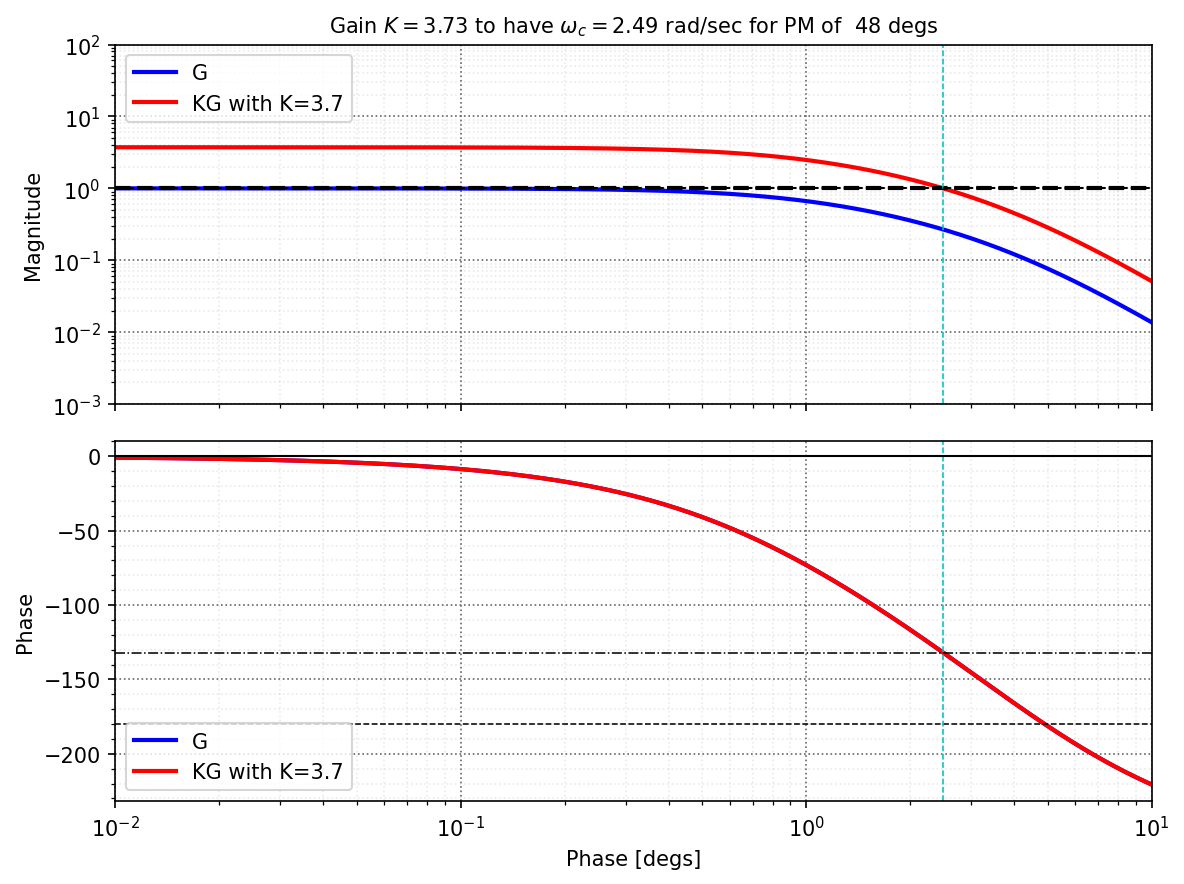

In [61]:
fig, ax = plt.subplots(2,1,figsize=(8, 6),dpi=150,sharex = True)
ax[0].loglog(Gw,Gm,'b-',label='G')
ax[0].loglog(Gw,K_wc*Gm,'r-',label='KG with K={:3.1f}'.format(K_wc))
ax[0].axhline(y=1,c='k',ls="--")
ax[0].axvline(x=wc_des,c='c',ls="--",lw=0.75)
ax[0].set_title(r'Gain $K=${:3.2f} to have $\omega_c=${:3.2f} rad/sec for PM of {:3.0f} degs'.format(K_wc,wc_des,PM))
ax[0].legend()
ax[0].set_ylim([.001,100])
ax[0].set_ylabel("Magnitude")

ax[1].semilogx(Gw,cm.wrap_phase_neg(Gp)*cm.r2d,'b-',label='G')
ax[1].semilogx(Gw,cm.wrap_phase_neg(Gp)*cm.r2d,'r-',label='KG with K={:3.1f}'.format(K_wc))
ax[1].axhline(y=-180,c='k',ls="--",lw=0.75)
ax[1].axhline(y=-180+PM,c='k',ls="-.",lw=0.75)
ax[1].axvline(x=wc_des,c='c',ls="--",lw=0.75)
ax[1].legend()
ax[1].set_xlim([min(w),max(w)])
ax[1].set_ylabel("Phase")
#ax[1].set_ylim([-270,0])
ax[1].set_xlabel("Frequency [rad/sec]")
ax[1].set_xlabel("Phase [degs]")
plt.legend()
bm.nicegrid(ax)
plt.savefig("./figs/L17_13.pdf", dpi=600)
plt.show()


## <a id='toc1_2_'></a>[Design Lag to decrease SS error by factor of 10 (keep PM of about 42)](#toc0_)

In [62]:
Gc_lag = cm.lag_design(gain_inc = 10, gamma = 10, wc = wc_des)
cm.write_tf_latex(Gc_lag, label="G_{c_{lag}}(s)",show=True, filename="./figs/L17_14.tex")

L_lag = K_wc*G*Gc_lag
Gcl_K = ct.feedback(K_wc*G,1)
Gcl_lag = ct.feedback(L_lag,1)

[Gm,Gp,Gw] = ct.frequency_response(K_wc*G,omega=w)
[Gcm,Gcp,Gcw] = ct.frequency_response(Gc_lag,omega=w)
[Lcm,Lcp,Lcw] = ct.frequency_response(L_lag,omega=w)

PM_gain = cm.find_PM(w,K_wc*G)
PM_lag = cm.find_PM(w,L_lag)

print(f"PM with gain only: {PM_gain[0]:.2f} degs")
print(f"PM with lag: {PM_lag[0]:.2f} degs")

Kp_gain = cm.find_Kp(K_wc*G)
Kp_lag = cm.find_Kp(L_lag)
print(f"Kp with gain only: {Kp_gain:.2f}")
print(f"Kp with lag: {Kp_lag:.2f}")

<IPython.core.display.Math object>

PM with gain only: 47.98 degs
PM with lag: 42.69 degs
Kp with gain only: 3.73
Kp with lag: 37.30


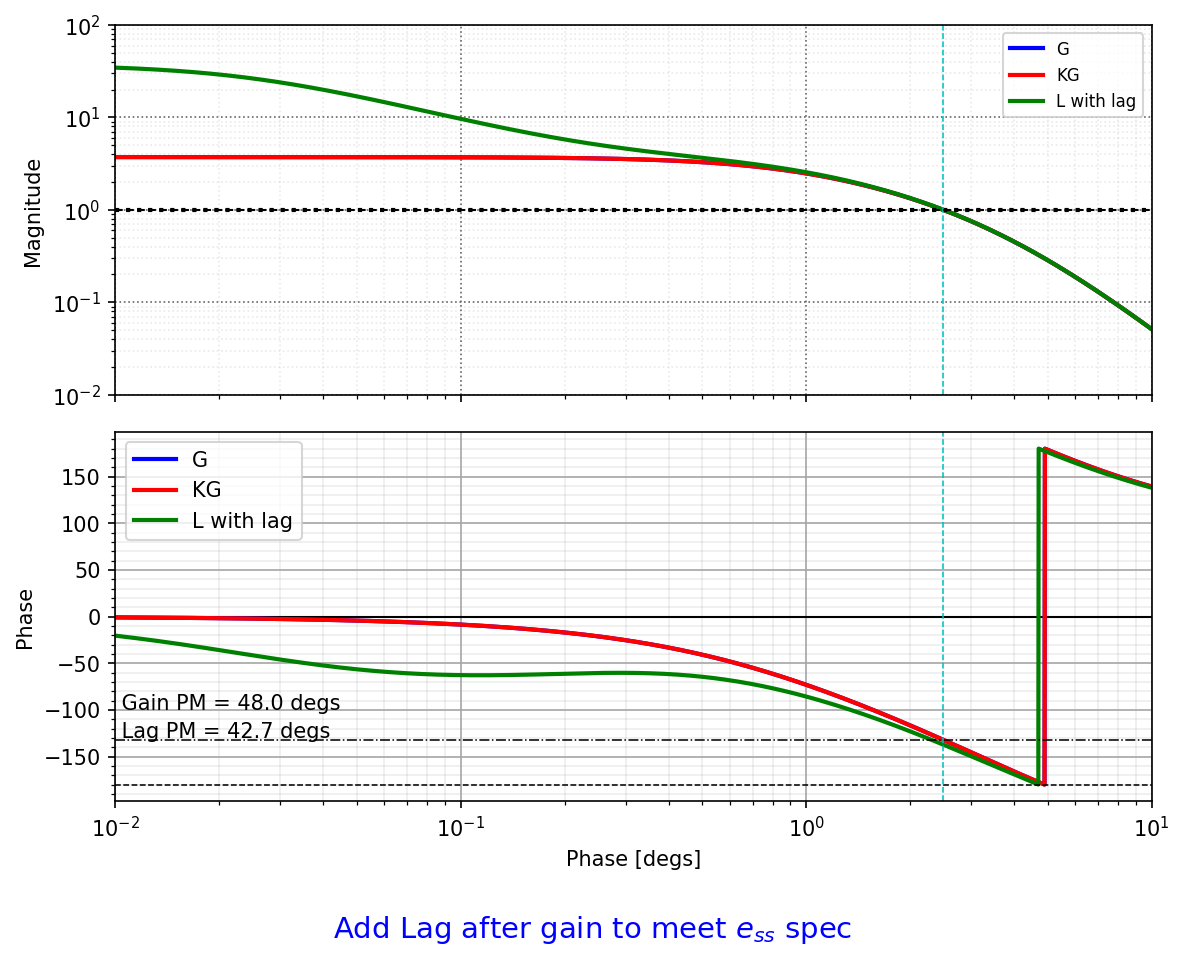

In [63]:
fig, ax = plt.subplots(2,1,figsize=(8, 6),dpi=150,sharex = True)
ax[0].loglog(Gw,Gm,'b-',label='G')
ax[0].loglog(Gw,Gm,'r-',label='KG')
ax[0].loglog(Lcw,Lcm,'g-',label='L with lag')
ax[0].axhline(y=1,c='k',ls=":")
ax[0].axvline(x=wc_des,c='c',ls="--",lw=0.75)
ax[0].legend(fontsize=8)
ax[0].set_ylim([.01,100])
ax[0].set_ylabel("Magnitude")
bm.nicegrid(ax)
ax[1].text(.01,-100,' Gain PM = {:.1f} degs'.format(PM_gain[0]))
ax[1].text(.01,-130,' Lag PM = {:.1f} degs'.format(PM_lag[0]))

ax[1].semilogx(Gw,cm.pshift(Gp)*cm.r2d,'b-',label='G')
ax[1].semilogx(Gw,cm.pshift(Gp)*cm.r2d,'r-',label='KG')
ax[1].semilogx(Lcw,cm.pshift(Lcp)*cm.r2d,'g-',label='L with lag')
ax[1].axhline(y=-180,c='k',ls="--",lw=0.75)
ax[1].axhline(y=-180+PM,c='k',ls="-.",lw=0.75)
ax[1].axvline(x=wc_des,c='c',ls="--",lw=0.75)
ax[1].legend(fontsize=8)
ax[1].set_xlim([min(w),max(w)])
ax[1].set_ylabel("Phase")
ax[1].grid(True, which="both", ls="-",color='0.65')
ax[1].set_xlabel("Frequency [rad/sec]")
ax[1].set_xlabel("Phase [degs]")
cm.caption("Add Lag after gain to meet $e_{ss}$ spec",fig)
plt.legend()
plt.savefig("./figs/L17_14.pdf", dpi=600)
plt.show()

## <a id='toc1_3_'></a>[check SS error in step](#toc0_)


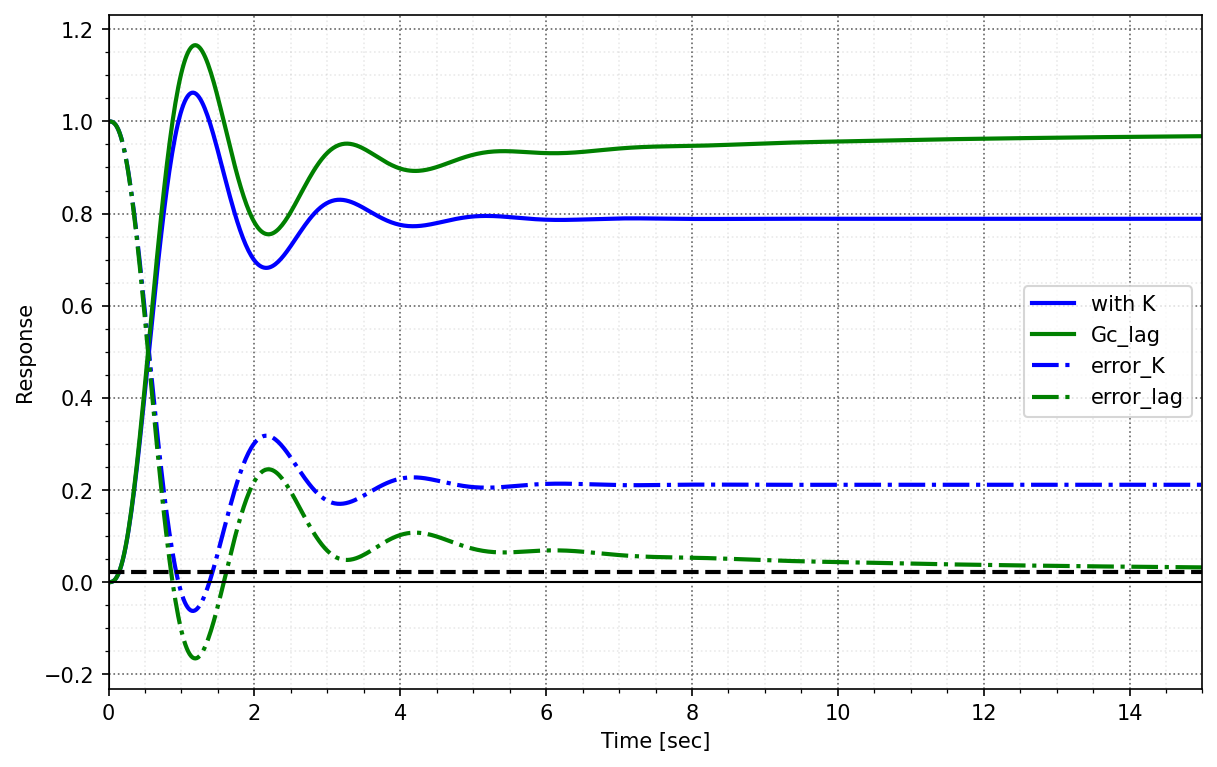

In [64]:
Tf = 15
y_K,t_K = cmat.step(Gcl_K,Tf)
y_lag,t_lag = cmat.step(Gcl_lag,Tf)

fig, ax = plt.subplots(1,figsize=(8, 5),dpi=150,constrained_layout = True)
ax.plot(t_K,y_K,'b-',label='with K')
ax.plot(t_lag,y_lag,'g-',label='Gc_lag')
ax.plot(t_K,1-y_K,'b-.',label='error_K')
ax.plot(t_lag,1-y_lag,'g-.',label='error_lag')
ax.axhline(y = (1-y_K[-1])/10,color='k',ls='--')
bm.nicegrid(ax)
ax.set_xlabel('Time [sec]')
ax.set_ylabel('Response')
plt.legend()
plt.savefig("./figs/L17_14a.pdf", dpi=600)
plt.show()
